# Per-iteration normalized-gate distribution — plot from cache

Plots the cached measurements produced by `gate_value_distribution.py`
(`analyze_model` → `.gate_dist_cache/<key>.npz` + `<key>.json`). **No model is
loaded here** — this notebook only reads the cache, so it is instant to re-run
(the notebook counterpart of `--plot-only`).

For each recurrence iteration `r`, the cache stores the distribution — across all
tokens — of the *normalized gate value* (`current_gates_normalized[r]`, per-token
mean over the embedding dim `D`). The cache holds, per iteration:

* `mean`, `std` across all tokens (the two numbers the training plot shows),
* an exact histogram over `[0, 1]` (`hist_edges`, `hist_counts`) — rebuild any density,
* a bounded per-token subsample (`sample`, shape `(K, n)`) — for violins.

Following the style of `input_vs_iteration_similarity.ipynb`, multiple cached
models can be overlaid on the same per-iteration `mean ± std` plot.

* Gate source: `src/modalities/models/gpt2/gpt2_model.py`
  (`CombinedRepresentationGPT2Block.current_gates_normalized`).
* Producer: `gate_value_distribution.py`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

CACHE_DIR = Path('./.gate_dist_cache')
PLOTS_DIR = Path('./plots')
PLOTS_DIR.mkdir(exist_ok=True)

## Configuration

Point at the cache(s) to plot. Leave `MODELS = None` to **auto-discover** every
`*.npz` cache in `CACHE_DIR` (label taken from each cache's JSON sidecar), or list
them explicitly to control labels / ordering — this is how you overlay, e.g., an
MTP vs. a non-MTP run on the same figure.

In [2]:
# Auto-discover every cache in CACHE_DIR ...
MODELS = None

# ... or list caches explicitly (label + npz path) to control labels & order:
# MODELS = [
#     {'label': 'MTP',    'cache': CACHE_DIR / 'model_611b887621.npz'},
#     {'label': 'no-MTP', 'cache': CACHE_DIR / 'other_abcdef1234.npz'},
# ]

print('CACHE_DIR =', CACHE_DIR.resolve())
print('Caches present:', [p.name for p in sorted(CACHE_DIR.glob('*.npz'))])

CACHE_DIR = /raid/s3/opengptx/behzad_shomali/modalities/.gate_dist_cache
Caches present: ['model_611b887621.npz']


## Load cached results

`load_cache(npz_path, label)` reads the `.npz` payload and its `.json` sidecar and
returns a small dict (`payload`, `meta`, and a tidy per-iteration `mean ± std`
`DataFrame`). Duplicate labels (e.g. two runs both labelled `model`) are
disambiguated with the cache-file stem.

In [3]:
def load_cache(npz_path, label=None):
    npz_path = Path(npz_path)
    payload = dict(np.load(npz_path))
    meta_path = npz_path.with_suffix('.json')
    meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
    if label is None:
        label = meta.get('label', npz_path.stem)
    df = pd.DataFrame({
        'label': label,
        'iteration': payload['iterations'].astype(int),
        'mean_gate': payload['mean'],
        'std_gate': payload['std'],
    })
    return {'label': label, 'npz': npz_path, 'payload': payload, 'meta': meta, 'df': df}


if MODELS is None:
    specs = [{'label': None, 'cache': p} for p in sorted(CACHE_DIR.glob('*.npz'))]
else:
    specs = MODELS
assert specs, f'No caches found. Run gate_value_distribution.py first (CACHE_DIR={CACHE_DIR}).'

loaded = [load_cache(s['cache'], s.get('label')) for s in specs]

# Disambiguate any colliding labels so overlays / legends stay readable.
seen = {}
for m in loaded:
    n = seen.get(m['label'], 0)
    seen[m['label']] = n + 1
    if n:
        m['label'] = f"{m['label']} ({m['npz'].stem})"
        m['df']['label'] = m['label']

results = pd.concat([m['df'] for m in loaded], ignore_index=True)
for m in loaded:
    meta = m['meta']
    print(f"[{m['label']}] K={meta.get('K', '?')}  agg={meta.get('aggregation_type', '?')}  "
          f"n_tokens={meta.get('n_tokens', '?'):,}  ckpt={meta.get('checkpoint_path', '?')}")
results

[model] K=5  agg=WS  n_tokens=1,048,576  ckpt=/leonardo_scratch/large/userexternal/bshomali/checkpoints/2026-05-28__01-27-04_7dac93dbde1d0c9e


,label,iteration,mean_gate,std_gate
0,model,1,0.189570,0.016647
1,model,2,0.170973,0.016715
2,model,3,0.169015,0.016727
3,model,4,0.205763,0.028680
4,model,5,0.264679,0.044745


## Per-iteration `mean ± std` (across tokens)

The direct analogue of the training-time "Normalized Gate Value" plot and of the
similarity notebook's overlay: one `mean ± std` curve per cached model.

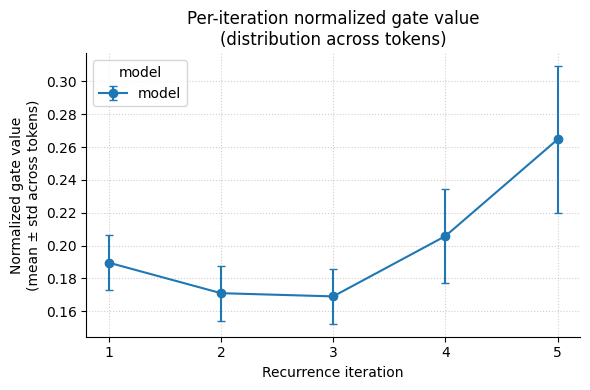

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in loaded:
    grp = m['df']
    ax.errorbar(grp['iteration'], grp['mean_gate'], yerr=grp['std_gate'],
                marker='o', capsize=3, linewidth=1.5, label=m['label'])
ax.set_xlabel('Recurrence iteration')
ax.set_ylabel('Normalized gate value\n(mean ± std across tokens)')
ax.set_title('Per-iteration normalized gate value\n(distribution across tokens)')
ax.set_xticks(sorted(results['iteration'].unique()))
ax.legend(title='model')
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'gate_value_per_iteration_meanstd.pdf')
plt.show()

## Distribution per iteration — violin

Uses the cached per-token `sample` (bounded subsample) to show the full spread of
the normalized gate value at each iteration. One figure per cached model; the
black markers repeat `mean ± std`.

In [13]:
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

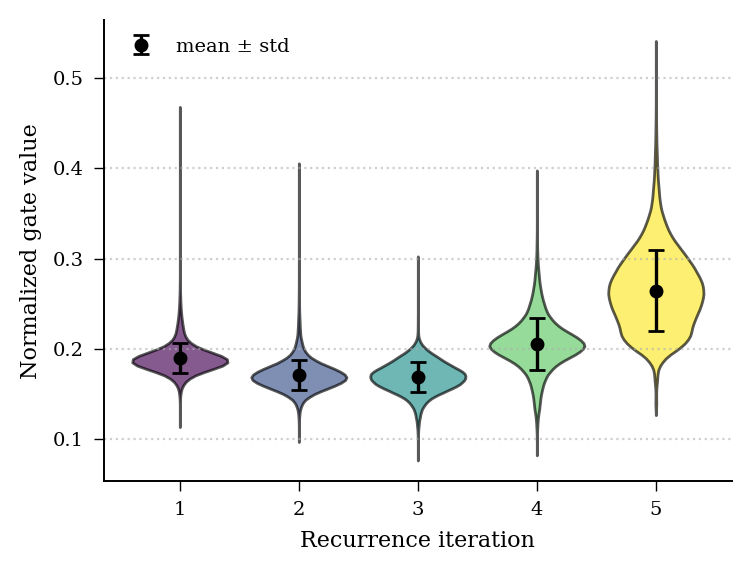

In [19]:
for m in loaded:
    payload, meta = m['payload'], m['meta']
    iters = payload['iterations'].astype(int)
    K = len(iters)
    sample = payload['sample']                       # (K, n) float16
    data = [sample[r].astype(np.float64) for r in range(K)]
    positions = list(range(1, K + 1))

    fig, ax = plt.subplots(figsize=(3.8, 2.9))
    parts = ax.violinplot(data, positions=positions, showmeans=False,
                          showextrema=False, widths=0.8)
    cmap = plt.get_cmap('viridis')
    for i, body in enumerate(parts['bodies']):
        body.set_facecolor(cmap(i / max(K - 1, 1)))
        body.set_edgecolor('black')
        body.set_alpha(0.65)
    ax.errorbar(positions, payload['mean'], yerr=payload['std'], fmt='o',
                color='black', capsize=3, markersize=4, linewidth=1.2,
                label='mean ± std')

    ax.set_xlabel('Recurrence iteration')
    ax.set_ylabel('Normalized gate value')
    ax.set_xticks(positions)
    ax.set_xticklabels([str(i) for i in iters], )
    # ax.set_title(f"Per-iteration normalized-gate distribution")
                #  f"[{m['label']}]  K={meta.get('K', K)}, {meta.get('n_tokens', 0):,} tokens")
    ax.legend(loc='best', frameon=False)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"gate_value_distribution_{m['label']}_violin.pdf")
    plt.show()

## Distribution per iteration — exact density (histogram)

Reconstructs the exact normalized density from the cached histogram
(`hist_counts` / `hist_edges`, computed over **all** tokens, not just the
subsample). One figure per cached model, one curve per iteration.

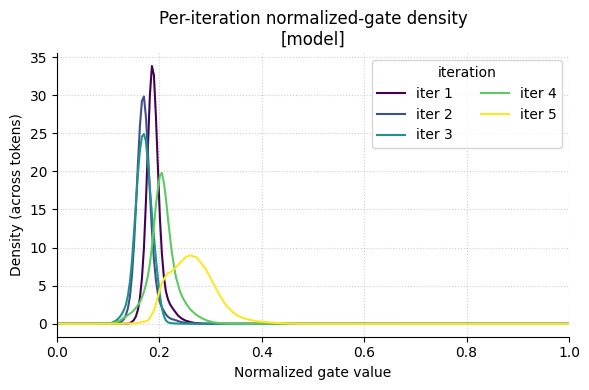

In [6]:
for m in loaded:
    payload, meta = m['payload'], m['meta']
    edges = payload['hist_edges']
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    counts = payload['hist_counts']                  # (K, n_bins)
    K = counts.shape[0]

    fig, ax = plt.subplots(figsize=(6, 4))
    cmap = plt.get_cmap('viridis')
    for r in range(K):
        total = counts[r].sum()
        density = counts[r] / total / widths if total > 0 else counts[r] * 0.0
        ax.plot(centers, density, color=cmap(r / max(K - 1, 1)),
                linewidth=1.5, label=f'iter {r + 1}')
    ax.set_xlabel('Normalized gate value')
    ax.set_ylabel('Density (across tokens)')
    ax.set_xlim(0, 1)
    ax.set_title(f"Per-iteration normalized-gate density\n[{m['label']}]")
    ax.legend(title='iteration', ncol=2)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"gate_value_density_{m['label']}.pdf")
    plt.show()